# ConvNeXt-Tiny

This notebook trains a second TwinCar classifier using ConvNeXt-Tiny as the backbone.
It uses the **exact same training recipe** as the EfficientNet-B0 - same dataset, same splits, same augmentation, same
single-phase full fine-tuning with `ReduceLROnPlateau`, mixed precision, and early
stopping. The only thing that differs is the architecture, so any accuracy gap is
attributable to the model, not the training procedure.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
import shutil
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import ConvNeXt_Tiny_Weights

PROJECT_DIR    = Path("/content/drive/MyDrive/twincar")
DATA_DIR       = Path("/content/twincar_data")
STANFORD_CACHE = PROJECT_DIR / "stanford_cars_cache"
METADATA_PATH  = PROJECT_DIR / "data" / "stanford_metadata.csv"
MODEL_DIR      = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CONVNEXT_DIR = MODEL_DIR / "convnext_tiny"
CONVNEXT_DIR.mkdir(parents=True, exist_ok=True)

SEED       = 42
IMG_SIZE   = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device      :", device)
print("CONVNEXT_DIR:", CONVNEXT_DIR)

Device      : cuda
CONVNEXT_DIR: /content/drive/MyDrive/twincar/models/convnext_tiny


## Copy Images to Local Storage

Images are loaded from the HuggingFace cache on Drive and written to the local
`/content/twincar_data/` folder in ImageFolder format.

In [ ]:
def count_images(split):
    split_path = DATA_DIR / split
    if not split_path.exists():
        return 0
    return sum(len(list((split_path / c).glob("*.jpg"))) for c in os.listdir(split_path))


def sanitize(name):
    return name.replace(" ", "_").replace("/", "-")


needs_copy = any(count_images(s) == 0 for s in ["train", "val", "test"])

if needs_copy:
    print("Copying images from HuggingFace cache to local storage...")

    from datasets import load_dataset

    dataset  = load_dataset("naufalso/stanford_cars", cache_dir=STANFORD_CACHE)
    metadata = pd.read_csv(METADATA_PATH)

    train_df = metadata[metadata["split"] == "train"].reset_index(drop=True)
    val_df   = metadata[metadata["split"] == "val"].reset_index(drop=True)
    test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)

    for split_name in ["train", "val", "test"]:
        split_dir = DATA_DIR / split_name
        if split_dir.exists():
            shutil.rmtree(split_dir)
        split_dir.mkdir(parents=True, exist_ok=True)

    for df_split, split_name, src_split in [
        (train_df, "train", "train"),
        (val_df,   "val",   "train"),
        (test_df,  "test",  "test"),
    ]:
        split_dir = DATA_DIR / split_name
        for _, row in df_split.iterrows():
            class_dir = split_dir / sanitize(row["class_name"])
            class_dir.mkdir(parents=True, exist_ok=True)
            img = dataset[src_split][int(row["hf_idx"])]["image_path"]
            img.save(class_dir / f"{int(row['hf_idx'])}.jpg")
        print(f"  {split_name}: {len(df_split)} images copied")

    del dataset

else:
    print("Image folders already populated — skipping copy.")

print()
for s in ["train", "val", "test"]:
    print(f"  {s}: {count_images(s)} images")

Copying images from HuggingFace cache to local storage...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

  train: 6887 images copied
  val: 1216 images copied
  test: 8000 images copied

  train: 6887 images
  val: 1216 images
  test: 8000 images


## Augmentation and DataLoaders

The augmentation is **identical** to the EfficientNet-B0 run so that any accuracy
difference between the two models is attributable to architecture, not data.

| Transform | Purpose |
|---|---|
| `RandomResizedCrop(224, scale=0.8–1.0)` | Scale and crop variation |
| `RandomHorizontalFlip(p=0.5)` | Left/right direction |
| `RandomRotation(10°)` | Camera tilt |
| `ColorJitter(0.2, 0.2, 0.1, 0.02)` | Lighting and colour variation |

A `WeightedRandomSampler` balances the mild class imbalance (24–68 images/class),
exactly as in the B0 run.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(f"{DATA_DIR}/val",   transform=val_test_transforms)

assert train_dataset.class_to_idx == val_dataset.class_to_idx, "Class mapping mismatch!"

targets        = train_dataset.targets
class_counts   = Counter(targets)
class_weights  = {cid: 1.0 / cnt for cid, cnt in class_counts.items()}
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

NUM_WORKERS = 2 if os.cpu_count() > 1 else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Classes       : {len(train_dataset.classes)}")

Train batches : 216
Val batches   : 38
Classes       : 195


## Save Class Index Map

The model outputs an integer 0–194; to turn that into a class name like
`BMW X5 SUV 2007` we need the index → class-name mapping. `ImageFolder` assigns
these indices alphabetically by folder name, so the mapping is reproducible, but we
save it explicitly to `idx_to_class.json` so the evaluation notebook and any
standalone inference script can decode predictions without needing an `ImageFolder`.

In [ ]:
import json

# idx -> sanitised class folder name (e.g. 42 -> 'BMW_X5_SUV_2007')
idx_to_class = {idx: name for name, idx in train_dataset.class_to_idx.items()}

idx_map_path = CONVNEXT_DIR / "idx_to_class.json"
with open(idx_map_path, "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved idx_to_class.json to:", idx_map_path)
print("Number of classes:", len(idx_to_class))
print("First 3:", dict(list(idx_to_class.items())[:3]))

Saved idx_to_class.json to: /content/drive/MyDrive/twincar/models/convnext_tiny/idx_to_class.json
Number of classes: 195
First 3: {0: 'AM_General_Hummer_SUV_2000', 1: 'Acura_Integra_Type_R_2001', 2: 'Acura_RL_Sedan_2012'}


## Model: ConvNeXt-Tiny

In [ ]:
NUM_CLASSES = len(train_dataset.classes)  # 195

model = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

# Replace only the final Linear layer; keep LayerNorm and Flatten
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

# Single-phase: entire network trainable from the start (no freezing)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 140MB/s] 


Trainable params: 27,970,083 / 27,970,083


## Save Config to Drive

Hyperparameters are saved to `convnext_tiny/train_config.json`. These match the B0
config exactly except for the model name, so the evaluation notebook can load either
model with the same code.

In [ ]:
EPOCHS       = 30
LR           = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 5
LR_PATIENCE  = 2

train_config = {
    "model":           "convnext_tiny",
    "num_classes":     NUM_CLASSES,
    "img_size":        IMG_SIZE,
    "batch_size":      BATCH_SIZE,
    "seed":            SEED,
    "epochs":          EPOCHS,
    "lr":              LR,
    "weight_decay":    WEIGHT_DECAY,
    "patience":        PATIENCE,
    "lr_patience":     LR_PATIENCE,
    "label_smoothing": 0.1,
    "imagenet_mean":   IMAGENET_MEAN,
    "imagenet_std":    IMAGENET_STD,
}

config_path = CONVNEXT_DIR / "train_config.json"
with open(config_path, "w") as f:
    json.dump(train_config, f, indent=4)

print("Saved train_config.json to:", config_path)

Saved train_config.json to: /content/drive/MyDrive/twincar/models/convnext_tiny/train_config.json


## Loss, Optimizer, Scheduler

Identical setup to the B0 run: AdamW over all parameters, cross-entropy with label
smoothing, `ReduceLROnPlateau` on validation loss, and mixed precision via
`autocast` + `GradScaler`.

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=train_config["label_smoothing"])

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

# Sanity check — single forward pass
model.eval()
with torch.no_grad():
    batch_imgs, _ = next(iter(train_loader))
    out = model(batch_imgs.to(device))
    assert out.shape == (batch_imgs.size(0), NUM_CLASSES), "Shape mismatch!"
    print(f"Forward pass OK — output shape: {out.shape}")
model.train()

Forward pass OK — output shape: torch.Size([32, 195])


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

## Training Helpers

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss   = 0.0
    correct_top1 = 0
    correct_top5 = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct_top1 += (logits.argmax(1) == labels).sum().item()
        _, p5 = logits.topk(5, dim=1)
        correct_top5 += (p5 == labels.unsqueeze(1)).any(1).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct_top1 / n, correct_top5 / n


def save_checkpoint(path, epoch, model, optimizer, scheduler, history, best_val_loss):
    torch.save(
        {
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history":              history,
            "best_val_loss":        best_val_loss,
        },
        path,
    )


print("Helper functions defined.")

Helper functions defined.


## Training Loop

Full fine-tuning with early stopping. Best model (lowest validation loss) saved to
`convnext_tiny/best_model.pt`. Training stops after `PATIENCE` epochs without
improvement.

ConvNeXt-Tiny is ~5× larger than B0, so expect each epoch to take noticeably longer
on the T4.

In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "train_top1": [], "val_top1": [], "val_top5": [],
    "lr":         [],
}

best_val_loss  = float("inf")
best_ckpt_path = CONVNEXT_DIR / "best_model.pt"
wait = 0

print("=" * 64)
print("TRAINING ConvNeXt-Tiny — full fine-tuning, ReduceLROnPlateau, early stopping")
print("=" * 64)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_top1, _ = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_top1, val_top5 = run_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_top1"].append(train_top1)
    history["val_top1"].append(val_top1)
    history["val_top5"].append(val_top5)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"| train_loss {train_loss:.4f} "
        f"| val_loss {val_loss:.4f} "
        f"| top1 {val_top1:.3f} "
        f"| top5 {val_top5:.3f} "
        f"| lr {current_lr:.2e} "
        f"| {elapsed:.0f}s"
    )

    save_checkpoint(CONVNEXT_DIR / "last_checkpoint.pt", epoch, model, optimizer, scheduler, history, best_val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), best_ckpt_path)
        print(f"  -> val loss improved to {best_val_loss:.4f} — saved best_model.pt (top1 {val_top1:.3f})")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no val-loss improvement for {PATIENCE} epochs).")
            break

best_idx = int(np.argmin(history["val_loss"]))
print()
print(f"Training complete. Best epoch: {best_idx + 1} "
      f"| val_loss {history['val_loss'][best_idx]:.4f} "
      f"| val top1 {history['val_top1'][best_idx]:.3f} "
      f"| val top5 {history['val_top5'][best_idx]:.3f}")

TRAINING ConvNeXt-Tiny — full fine-tuning, ReduceLROnPlateau, early stopping
Epoch 01/30 | train_loss 3.9475 | val_loss 2.7100 | top1 0.515 | top5 0.792 | lr 3.00e-04 | 146s
  -> val loss improved to 2.7100 — saved best_model.pt (top1 0.515)
Epoch 02/30 | train_loss 1.7013 | val_loss 1.8005 | top1 0.739 | top5 0.940 | lr 3.00e-04 | 102s
  -> val loss improved to 1.8005 — saved best_model.pt (top1 0.739)
Epoch 03/30 | train_loss 1.2594 | val_loss 1.6734 | top1 0.776 | top5 0.947 | lr 3.00e-04 | 108s
  -> val loss improved to 1.6734 — saved best_model.pt (top1 0.776)
Epoch 04/30 | train_loss 1.1382 | val_loss 1.5943 | top1 0.792 | top5 0.956 | lr 3.00e-04 | 107s
  -> val loss improved to 1.5943 — saved best_model.pt (top1 0.792)
Epoch 05/30 | train_loss 1.0541 | val_loss 1.6376 | top1 0.787 | top5 0.947 | lr 3.00e-04 | 108s
Epoch 06/30 | train_loss 1.0372 | val_loss 1.5266 | top1 0.821 | top5 0.959 | lr 3.00e-04 | 102s
  -> val loss improved to 1.5266 — saved best_model.pt (top1 0.821)
E

## Training Curves

Same three-panel layout as the B0 notebook so the two runs can be compared directly.

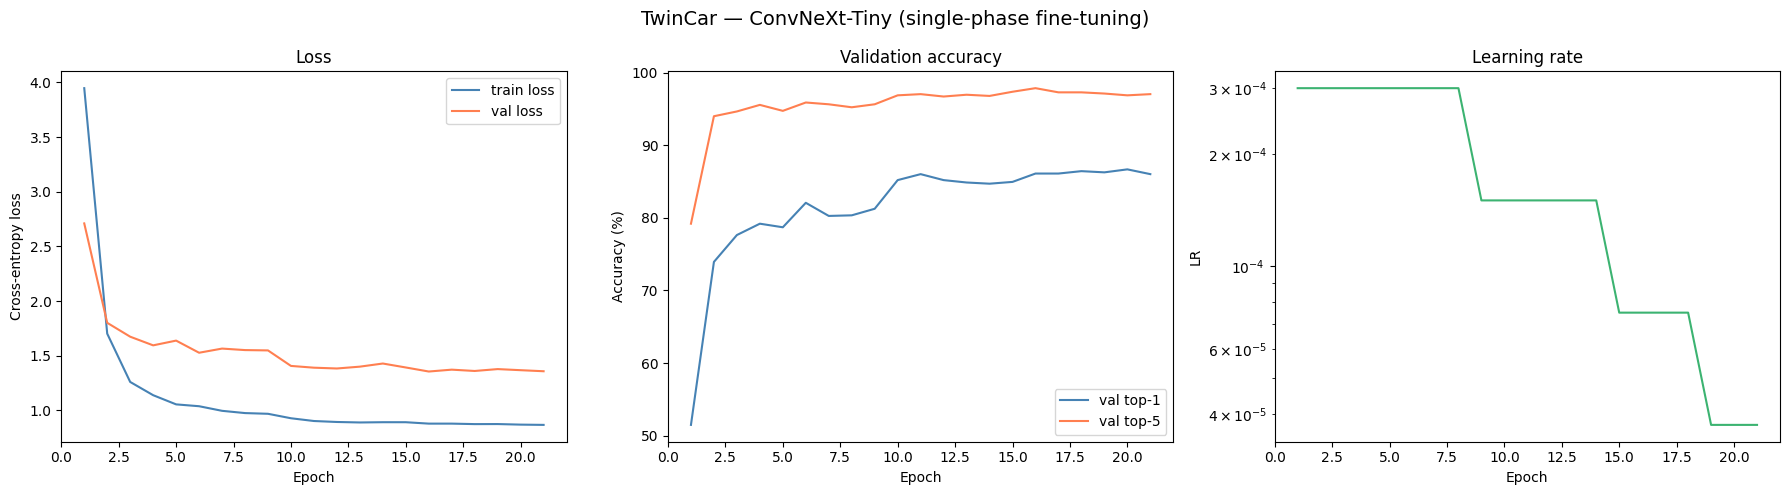

Saved training curves to: /content/drive/MyDrive/twincar/models/convnext_tiny/training_curves.png


In [ ]:
n_epochs = len(history["train_loss"])
epochs_axis = list(range(1, n_epochs + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(epochs_axis, history["train_loss"], label="train loss", color="steelblue")
ax.plot(epochs_axis, history["val_loss"],   label="val loss",   color="coral")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()

ax = axes[1]
ax.plot(epochs_axis, [v * 100 for v in history["val_top1"]], label="val top-1", color="steelblue")
ax.plot(epochs_axis, [v * 100 for v in history["val_top5"]], label="val top-5", color="coral")
ax.set_title("Validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()

ax = axes[2]
ax.plot(epochs_axis, history["lr"], color="mediumseagreen")
ax.set_title("Learning rate")
ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.set_yscale("log")

plt.suptitle("TwinCar - ConvNeXt-Tiny (single-phase fine-tuning)", fontsize=14)
plt.tight_layout()

curves_path = CONVNEXT_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved training curves to:", curves_path)

## Summary

Files saved to `twincar/models/convnext_tiny/` on Drive:

| File | Description |
|---|---|
| `best_model.pt` | State dict of the lowest-val-loss epoch |
| `last_checkpoint.pt` | Full resumable checkpoint (last epoch) |
| `train_config.json` | All hyperparameters |
| `training_curves.png` | Loss, accuracy, and LR plots |

In [ ]:
print("Files in convnext_tiny/:")
for f in sorted(CONVNEXT_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name:40s} {f.stat().st_size/1e6:.1f} MB")

best_idx = int(np.argmin(history["val_loss"]))
print()
print(f"Best epoch     : {best_idx + 1}")
print(f"Best val top-1 : {history['val_top1'][best_idx]*100:.2f}%")
print(f"Best val top-5 : {history['val_top5'][best_idx]*100:.2f}%")

Files in convnext_tiny/:
  best_model.pt                            111.9 MB
  idx_to_class.json                        0.0 MB
  last_checkpoint.pt                       335.9 MB
  train_config.json                        0.0 MB
  training_curves.png                      0.1 MB

Best epoch     : 16
Best val top-1 : 86.10%
Best val top-5 : 97.86%
